# BLEU from Scratch — A Runnable Tutorial

**BLEU** (Bilingual Evaluation Understudy) measures how much a machine-generated text overlaps with a human **reference**, by counting shared **n-grams** (contiguous word sequences). Invented for machine translation, it's used anywhere you have a gold reference: translation, summarization, paraphrasing.

This notebook builds BLEU **piece by piece** — every formula is a small runnable cell you can poke at. By the end you'll have re-implemented the same `bleu()` used in this repo's eval harness (`evals/metrics.py`) and understood *why* a great summary can still score near zero.

**Contents**
1. Tokenization & n-grams
2. Modified n-gram precision (and why "modified")
3. Combining orders with the geometric mean
4. The brevity penalty
5. Smoothing (why sentence-level BLEU needs it)
6. Putting it all together — the full `bleu()`
7. The real `sum-rain` case: why a good summary scored 0.06
8. BLEU's biases, visualized
9. (Optional) cross-check vs. a reference implementation

No third-party libraries are required for sections 1–8 — only the Python standard library. `matplotlib` is used for the plots in section 8.

## 1. Tokenization & n-grams

BLEU works on **tokens**, not raw characters. We lowercase and split on word characters — the same simple tokenizer as `evals/metrics.py`. (Production tools like `sacrebleu` use a standardized tokenizer so scores are comparable across papers; for learning, simple is clearer.)

An **n-gram** is a window of `n` consecutive tokens.

In [5]:
import re
import math
from collections import Counter

def tokens(text):
    """Lowercase and split into word tokens."""
    return re.findall(r"\w+", text.lower())

def ngrams(toks, n):
    """All n-grams (as tuples) in a token list."""
    return [tuple(toks[i:i + n]) for i in range(len(toks) - n + 1)]

s = "The cat sat on the mat"
print("tokens: ", tokens(s))
print("1-grams:", ngrams(tokens(s), 1))
print("2-grams:", ngrams(tokens(s), 2))
print("3-grams:", ngrams(tokens(s), 3))

tokens:  ['the', 'cat', 'sat', 'on', 'the', 'mat']
1-grams: [('the',), ('cat',), ('sat',), ('on',), ('the',), ('mat',)]
2-grams: [('the', 'cat'), ('cat', 'sat'), ('sat', 'on'), ('on', 'the'), ('the', 'mat')]
3-grams: [('the', 'cat', 'sat'), ('cat', 'sat', 'on'), ('sat', 'on', 'the'), ('on', 'the', 'mat')]


Notice `('the',)` appears **twice** in the 1-grams — the word "the" occurs at position 0 and 4. That repetition matters in the next step.

## 2. Modified n-gram precision

**Precision** for order `n` = *of the n-grams the candidate produced, how many appear in the reference?*

But plain precision is gameable. Consider:
```
candidate:  the the the the
reference:  the cat sat on the mat
```
Plain 1-gram precision = 4/4 = **1.0** — perfect score for nonsense! BLEU fixes this with **clipping**: each candidate n-gram can only be counted up to the number of times it appears in the reference. "the" appears twice in the reference, so at most 2 of the candidate's four "the"s count.

That clipped version is called **modified n-gram precision**.

In [6]:
def modified_precision(candidate, reference, n):
    """Clipped n-gram precision for a single order n."""
    cand_counts = Counter(ngrams(tokens(candidate), n))
    ref_counts = Counter(ngrams(tokens(reference), n))

    # Clip each candidate n-gram count to how often it appears in the reference.
    clipped = {g: min(c, ref_counts[g]) for g, c in cand_counts.items()}

    overlap = sum(clipped.values())
    total = sum(cand_counts.values())
    return overlap, total, (overlap / total if total else 0.0)

# The gaming example: clipping saves us
o, t, p = modified_precision("the the the the", "the cat sat on the mat", 1)
print(f"'the the the the'  -> clipped 1-gram precision = {o}/{t} = {p:.2f}  (not 1.0!)")

# A real candidate
for n in (1, 2, 3):
    o, t, p = modified_precision("the cat sat", "the cat sat on the mat", n)
    print(f"'the cat sat'  {n}-gram precision = {o}/{t} = {p:.2f}")

'the the the the'  -> clipped 1-gram precision = 2/4 = 0.50  (not 1.0!)
'the cat sat'  1-gram precision = 3/3 = 1.00
'the cat sat'  2-gram precision = 2/2 = 1.00
'the cat sat'  3-gram precision = 1/1 = 1.00


## 3. Combining orders with the geometric mean

BLEU combines precisions for `n = 1..4` (this is `max_n=4`). It uses a **geometric mean**, not an arithmetic one:

$$ \text{geo mean} = \exp\!\left(\frac{1}{N}\sum_{n=1}^{N} \log p_n\right) = \left(p_1 p_2 p_3 p_4\right)^{1/4} $$

**Why geometric?** If *any* order scores 0, the product is 0 and the whole score collapses. This is deliberate — matching single words (1-grams) is easy; matching 4-word runs proves **fluency and correct word order**. The geometric mean refuses to let strong unigram overlap hide the fact that the candidate is scrambled.

In [7]:
def geometric_mean(precisions):
    # A single zero -> log(0) = -inf -> exp(-inf) = 0. That's the point.
    if any(p == 0 for p in precisions):
        return 0.0
    return math.exp(sum(math.log(p) for p in precisions) / len(precisions))

# Same words, scrambled order: unigrams match perfectly, higher orders don't.
ref = "the cat sat on the mat"
for cand in ["the cat sat on the mat", "mat the on sat cat the"]:
    ps = [modified_precision(cand, ref, n)[2] for n in range(1, 5)]
    print(f"{cand!r:35} precisions={['%.2f' % p for p in ps]}  geo_mean={geometric_mean(ps):.3f}")

'the cat sat on the mat'            precisions=['1.00', '1.00', '1.00', '1.00']  geo_mean=1.000
'mat the on sat cat the'            precisions=['1.00', '0.00', '0.00', '0.00']  geo_mean=0.000


The scrambled sentence has **identical 1-gram precision** (same bag of words) but its 2/3/4-grams don't match, so the geometric mean crashes. Arithmetic mean would have masked this.

## 4. The brevity penalty

Precision rewards *not saying wrong things* — but you can maximize precision by saying **almost nothing**. Candidate `"the cat"` against a long reference has high precision but obviously isn't a good translation.

BLEU counters this with a **brevity penalty (BP)** that shrinks the score when the candidate is *shorter* than the reference:

$$ BP = \begin{cases} 1 & \text{if } c > r \\ e^{(1 - r/c)} & \text{if } c \le r \end{cases} $$

where `c` = candidate length, `r` = reference length. Note there's **no reward for being longer** — only a penalty for being too short. (Precision already discourages padding with wrong words.)

In [8]:
def brevity_penalty(candidate, reference):
    c = len(tokens(candidate))
    r = len(tokens(reference))
    if c == 0:
        return 0.0
    return 1.0 if c > r else math.exp(1 - r / c)

ref = "the cat sat on the mat"        # 6 tokens
for cand in ["the cat", "the cat sat on", "the cat sat on the mat", "the cat sat on the mat today"]:
    print(f"c={len(tokens(cand))} vs r={len(tokens(ref))}  BP={brevity_penalty(cand, ref):.3f}   {cand!r}")

c=2 vs r=6  BP=0.135   'the cat'
c=4 vs r=6  BP=0.607   'the cat sat on'
c=6 vs r=6  BP=1.000   'the cat sat on the mat'
c=7 vs r=6  BP=1.000   'the cat sat on the mat today'


Short candidates are penalized hard; matching or exceeding the reference length gives BP = 1.0.

## 5. Smoothing — why sentence-level BLEU needs it

BLEU was designed for **corpus-level** scoring (thousands of sentences pooled together), where some 4-gram somewhere always matches. But we often want a score for a **single short sentence** — and short sentences frequently have **zero** 4-gram matches. From section 3, one zero zeroes out everything.

The fix used in this repo is **add-1 (Laplace) smoothing**: add 1 to both numerator and denominator of each precision, so an empty higher-order slot yields a tiny positive number instead of 0.

$$ p_n = \frac{\text{overlap} + 1}{\text{total} + 1} $$

This is one of several smoothing schemes (Chen & Cherry 2014 catalogue seven). Corpus-level BLEU usually needs none; sentence-level almost always does.

In [9]:
def precision_smoothed(candidate, reference, n):
    overlap, total, _ = modified_precision(candidate, reference, n)
    return (overlap + 1) / (total + 1)   # add-1 smoothing

cand = "a small cat sat down"
ref = "the cat sat on the mat"
print("WITHOUT smoothing:")
for n in range(1, 5):
    _, _, p = modified_precision(cand, ref, n)
    print(f"  {n}-gram precision = {p:.3f}")
print("  -> geo mean =", round(geometric_mean([modified_precision(cand, ref, n)[2] for n in range(1,5)]), 3),
      "(a single 0 kills it)")

print("\nWITH add-1 smoothing:")
for n in range(1, 5):
    print(f"  {n}-gram precision = {precision_smoothed(cand, ref, n):.3f}")
print("  -> geo mean =", round(geometric_mean([precision_smoothed(cand, ref, n) for n in range(1,5)]), 3),
      "(survives)")

WITHOUT smoothing:
  1-gram precision = 0.400
  2-gram precision = 0.250
  3-gram precision = 0.000
  4-gram precision = 0.000
  -> geo mean = 0.0 (a single 0 kills it)

WITH add-1 smoothing:
  1-gram precision = 0.500
  2-gram precision = 0.400
  3-gram precision = 0.250
  4-gram precision = 0.333
  -> geo mean = 0.359 (survives)


## 6. Putting it all together

$$ \text{BLEU} = BP \times \exp\!\left(\frac{1}{N}\sum_{n=1}^{N} \log p_n\right) $$

This is a from-scratch re-implementation of `evals/metrics.py::bleu` — same tokenizer, same `max_n=4`, same add-1 smoothing, same brevity penalty.

In [10]:
def bleu(candidate, reference, max_n=4):
    """Sentence-level BLEU with add-1 smoothing and a brevity penalty."""
    cand, ref = tokens(candidate), tokens(reference)
    if not cand or not ref:
        return 0.0
    precisions = [precision_smoothed(candidate, reference, n) for n in range(1, max_n + 1)]
    geo = geometric_mean(precisions)
    bp = brevity_penalty(candidate, reference)
    return bp * geo

# Sanity checks
print("identical    :", round(bleu("the cat sat on the mat", "the cat sat on the mat"), 3))
print("paraphrase   :", round(bleu("a cat is sitting on the mat", "the cat sat on the mat"), 3))
print("unrelated    :", round(bleu("quantum physics is hard", "the cat sat on the mat"), 3))
print("scrambled    :", round(bleu("mat the on sat cat the", "the cat sat on the mat"), 3))

identical    : 1.0
paraphrase   : 0.366
unrelated    : 0.183
scrambled    : 0.302


Note that even the **identical** case isn't exactly 1.0 — that's the add-1 smoothing nudging precisions slightly below 1. For regression testing we care about *relative* scores and thresholds, not hitting a clean 1.0, so this is fine.

Let's confirm this matches the harness implementation exactly:

In [11]:
# Cross-check against the repo's own implementation.
import sys, os
sys.path.insert(0, os.path.abspath("."))
try:
    from evals.metrics import bleu as repo_bleu
    pairs = [
        ("the cat sat on the mat", "the cat sat on the mat"),
        ("a cat is sitting on the mat", "the cat sat on the mat"),
        ("quantum physics is hard", "the cat sat on the mat"),
    ]
    for c, r in pairs:
        mine, theirs = bleu(c, r), repo_bleu(c, r)
        print(f"ours={mine:.4f}  repo={theirs:.4f}  match={abs(mine-theirs) < 1e-9}   {c!r}")
except ImportError as e:
    print("Run this notebook from the repo root to import evals.metrics. Skipping.", e)

ours=1.0000  repo=1.0000  match=True   'the cat sat on the mat'
ours=0.3656  repo=0.3656  match=True   'a cat is sitting on the mat'
ours=0.1833  repo=0.1833  match=True   'quantum physics is hard'


## 7. The real `sum-rain` case — why a *good* summary scored 0.06

This is the single most important lesson about BLEU. In our eval harness, this case initially **failed** even though the model's answer was excellent:

In [12]:
reference = "Water evaporates, condenses into clouds, and falls as rain or snow."
model_answer = ("The water cycle is the continuous process of evaporation, "
                "condensation, and precipitation that circulates water "
                "between the Earth's surface and atmosphere.")

print(f"BLEU = {bleu(model_answer, reference):.3f}\n")
print("Per-order modified precision (unsmoothed):")
for n in range(1, 5):
    o, t, p = modified_precision(model_answer, reference, n)
    print(f"  {n}-gram: {o}/{t} matched = {p:.3f}")

print("\nShared 1-grams:", set(ngrams(tokens(model_answer),1)) & set(ngrams(tokens(reference),1)))

BLEU = 0.061

Per-order modified precision (unsmoothed):
  1-gram: 2/22 matched = 0.091
  2-gram: 0/21 matched = 0.000
  3-gram: 0/20 matched = 0.000
  4-gram: 0/19 matched = 0.000

Shared 1-grams: {('and',), ('water',)}


The summary is **semantically perfect** but BLEU scores it ~0.06. Why?

The model wrote **`evaporation`, `condensation`, `precipitation`** where the reference had **`evaporates`, `condenses`, `rain or snow`**. Same meaning, *different surface words* → almost no n-gram overlap. The only shared words are function words like `water`, `and`, `into`.

**This is BLEU's defining weakness: it is lexical, not semantic. It cannot see synonyms or paraphrase.** A perfect answer worded differently looks, to BLEU, much like a wrong answer.

That's exactly why in the harness we:
- set BLEU thresholds **low and empirically** (0.04–0.15), not to some idealized "good" score,
- pair BLEU with **ROUGE-L** (recall-oriented, LCS-based), and
- use an **LLM-as-a-judge** for open-ended answers where wording legitimately varies.

BLEU is a cheap, deterministic *tripwire* for gross degradation — never the sole verdict on quality.

## 8. BLEU's biases, visualized

Two experiments make BLEU's behavior tangible.

**(a) Length bias / brevity penalty:** truncate a perfect answer and watch the score fall.

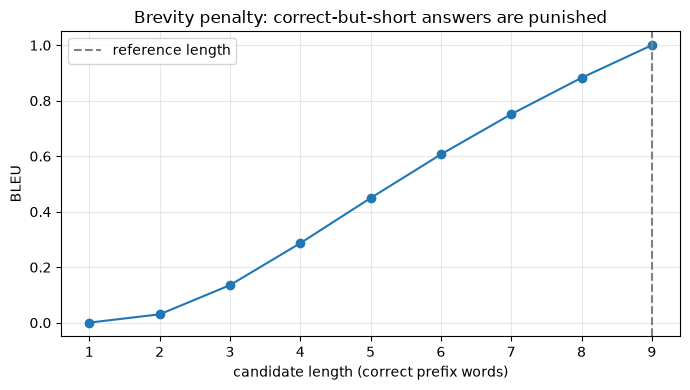

In [13]:
import matplotlib.pyplot as plt

reference = "the quick brown fox jumps over the lazy dog"
full = tokens(reference)
lengths, scores = [], []
for k in range(1, len(full) + 1):
    cand = " ".join(full[:k])          # first k correct words, in order
    lengths.append(k)
    scores.append(bleu(cand, reference))

plt.figure(figsize=(7, 4))
plt.plot(lengths, scores, marker="o")
plt.axvline(len(full), ls="--", color="gray", label="reference length")
plt.xlabel("candidate length (correct prefix words)")
plt.ylabel("BLEU")
plt.title("Brevity penalty: correct-but-short answers are punished")
plt.legend(); plt.grid(alpha=0.3); plt.tight_layout(); plt.show()

**(b) Paraphrase blindness:** swap in synonyms one at a time. Meaning is preserved; BLEU drops anyway.

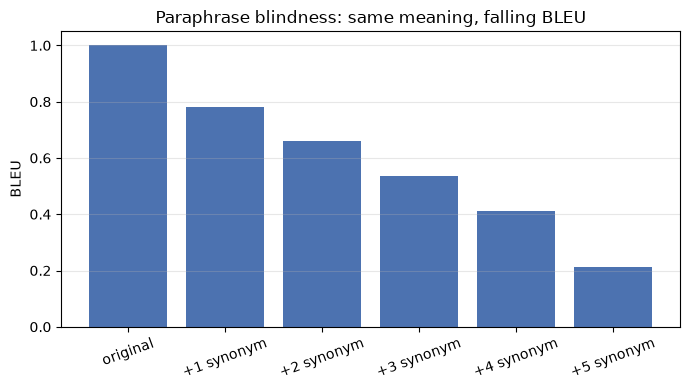

final sentence: the quick tan vixen jumps over the idle dog


In [14]:
reference = "the fast brown fox leaps over the lazy dog"
synonyms = {"fast": "quick", "brown": "tan", "fox": "vixen", "leaps": "jumps", "lazy": "idle"}

cand_words = tokens(reference)
labels, scores = ["original"], [bleu(reference, reference)]
swapped = list(cand_words)
for i, (orig, syn) in enumerate(synonyms.items(), 1):
    swapped = [syn if w == orig else w for w in swapped]
    labels.append(f"+{i} synonym")
    scores.append(bleu(" ".join(swapped), reference))

plt.figure(figsize=(7, 4))
plt.bar(labels, scores, color="#4C72B0")
plt.ylabel("BLEU"); plt.xticks(rotation=20)
plt.title("Paraphrase blindness: same meaning, falling BLEU")
plt.grid(axis="y", alpha=0.3); plt.tight_layout(); plt.show()
print("final sentence:", " ".join(swapped))

Every swapped sentence means the same thing to a human, yet BLEU decays with each substitution. This is why single-reference BLEU is unreliable for judging quality — and why the original BLEU paper recommends **multiple references** per example to cover legitimate wording variation.

## 9. (Optional) Cross-check vs. a reference implementation

If you have `nltk` or `sacrebleu` installed, compare. Values won't match *exactly* — different tokenizers and smoothing schemes — but should be in the same ballpark. This cell is optional and skips cleanly if neither is installed.

In [15]:
cand = "a cat is sitting on the mat"
ref = "the cat sat on the mat"
print(f"our bleu(): {bleu(cand, ref):.4f}\n")

try:
    from nltk.translate.bleu_score import sentence_bleu, SmoothingFunction
    smooth = SmoothingFunction().method1   # add-1-like smoothing
    nltk_score = sentence_bleu([tokens(ref)], tokens(cand), smoothing_function=smooth)
    print(f"nltk sentence_bleu (method1 smoothing): {nltk_score:.4f}")
except ImportError:
    print("nltk not installed  ->  pip install nltk   (optional)")

try:
    import sacrebleu
    # sacrebleu is corpus-level and uses its own tokenizer; single-sentence use is illustrative only.
    sb = sacrebleu.sentence_bleu(cand, [ref]).score / 100.0
    print(f"sacrebleu sentence_bleu: {sb:.4f}")
except ImportError:
    print("sacrebleu not installed  ->  pip install sacrebleu   (optional)")

our bleu(): 0.3656

nltk not installed  ->  pip install nltk   (optional)
sacrebleu not installed  ->  pip install sacrebleu   (optional)


## Recap

| Component | Role | In our code |
|---|---|---|
| **Modified n-gram precision** | overlap with reference, clipped to stop repetition-gaming | `modified_precision` |
| **Geometric mean (n=1..4)** | rewards fluency & word order; one zero → zero | `geometric_mean` |
| **Brevity penalty** | punishes too-short candidates | `brevity_penalty` |
| **Add-1 smoothing** | keeps short-sentence BLEU from collapsing to 0 | `precision_smoothed` |

$$ \text{BLEU} = \underbrace{BP}_{\text{length}} \times \underbrace{\exp\!\Big(\tfrac{1}{N}\textstyle\sum \log p_n\Big)}_{\text{n-gram precision}} $$

**Key takeaways**
- BLEU is **lexical**: it measures word overlap, not meaning. Synonyms and paraphrase tank it (section 7).
- It's **fast, deterministic, and reproducible** — ideal as a regression *tripwire*, not a quality oracle.
- Use **multiple references** when you can; pair with **ROUGE-L** and an **LLM judge** when you can't.
- For real projects prefer a standardized implementation (`sacrebleu`) so scores are comparable; this from-scratch version is for understanding.